This notebook trains a Linear Regression model to predict the next-day closing price of Bitcoin (BTC-USD) using features engineered from historical OHLCV (Open, High, Low, Close, Volume) data — including rolling averages and price ratios across multiple time horizons. Hyperparameters are tuned with RandomizedSearchCV using time-series cross-validation and the model is evaluated with MAE, MSE, RMSE, and R².

In [1]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
import pickle

In [2]:
# Load the data
btc_ticker = yf.Ticker("BTC-USD")
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(start="2014-09-17", end="2024-09-01")
    btc.to_csv("btc.csv")

In [3]:
# Preprocess the data
btc = btc.drop(columns=["Dividends", "Stock Splits"])
btc.index = pd.to_datetime(btc.index)
btc.index = btc.index.tz_localize(None)

In [4]:
def compute_rolling(btc):
    horizons = [2,7,60,365]

    for horizon in horizons:
        rolling_averages = btc.rolling(horizon, min_periods=1).mean()

        ratio_column = f"open_ratio_{horizon}"
        btc[ratio_column] = btc["Open"] / rolling_averages["Open"]

        rolling = btc.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["Open"]

        btc = btc.dropna()

    return btc

In [5]:
btc = compute_rolling(btc)

/tmp/ipykernel_5405/1502108625.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[ratio_column] = btc["Open"] / rolling_averages["Open"]
/tmp/ipykernel_5405/1502108625.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[trend_column] = rolling["Open"]


In [6]:
btc_features = ['Open', 'High', 'Low', 'Volume', 'open_ratio_2', 'trend_2', 'open_ratio_7', 'trend_7', 'open_ratio_60', 'trend_60', 'open_ratio_365', 'trend_365']
X = btc[btc_features]
y = btc['Close']

In [7]:
# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Split the data into training and testing sets
train_len = int(len(X) * 0.8)
X_train, X_test = X_scaled[0:train_len], X_scaled[train_len:len(X)]
y_train, y_test = y[0:train_len], y[train_len:len(X)]

In [9]:
# Set up the hyperparameter grid for GridSearchCV
parameters = {
    'fit_intercept': [True, False]
}

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Define the TimeSeriesSplit object
tscv = TimeSeriesSplit(n_splits=3)

# Set up GridSearchCV
random_search = RandomizedSearchCV(estimator=lr_model, param_distributions=parameters, cv=tscv, verbose=1, n_jobs=-1, scoring='neg_mean_squared_error', random_state=1)
random_search.fit(X_train, y_train)

best_lr = random_search.best_estimator_

# Make predictions
y_pred = best_lr.predict(X_test)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [10]:
print(random_search.best_params_)

{'fit_intercept': True}


In [11]:
# # Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"LR - Srednja apsolutna pogreška: {mae}")
print(f"LR - Srednja kvadratna pogreška: {mse}")
print(f"LR - Korijen srednje kvadratne pogreške: {rmse}")
print(f"LR - R^2 Score: {r2}")

LR - Srednja apsolutna pogreška: 264.57885391213085
LR - Srednja kvadratna pogreška: 159434.0107860451
LR - Korijen srednje kvadratne pogreške: 399.2918867020029
LR - R^2 Score: 0.9994898987522359


In [12]:

# Reshape y_test and y_pred to 2D arrays for the scaler
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)

# Min-Max scale y_test and y_pred
scaler = StandardScaler()
y_test_scaled = scaler.fit_transform(y_test_reshaped)
y_pred_scaled = scaler.transform(y_pred_reshaped)

# Calculate the metrics on the scaled data
mae_scaled_rf = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse_scaled_rf = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse_scaled_rf = np.sqrt(mse_scaled_rf)
r2_scaled_rf = r2_score(y_test_scaled, y_pred_scaled)

print(f"LR - Scaled Mean Absolute Error: {mae_scaled_rf}")
print(f"LR - Scaled Mean Squared Error: {mse_scaled_rf}")
print(f"LR - Scaled Root Mean Squared Error: {rmse_scaled_rf}")
print(f"LR - Scaled R-squared: {r2_scaled_rf}")

LR - Scaled Mean Absolute Error: 0.014965555368284224
LR - Scaled Mean Squared Error: 0.0005101012477641032
LR - Scaled Root Mean Squared Error: 0.022585421133202346
LR - Scaled R-squared: 0.9994898987522359


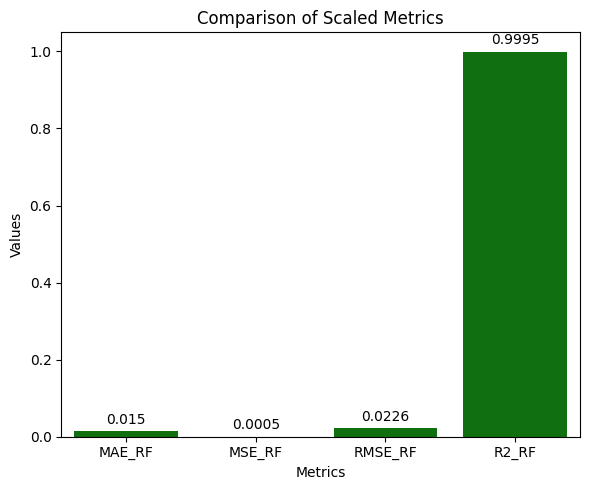

In [13]:
# Prepare data for plotting
metrics = ['MAE_RF', 'MSE_RF', 'RMSE_RF', 'R2_RF']
scaled_values = [mae_scaled_rf, mse_scaled_rf, rmse_scaled_rf, r2_scaled_rf]

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({'Metric': metrics, 'Value': scaled_values})

# Plotting the scaled metrics using seaborn
plt.figure(figsize=(6, 5))
sns.barplot(x='Metric', y='Value', data=metrics_df, color="green")

# Add some text for labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 4)),  # rounded to 4 decimal places for better precision
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Get the current Axes instance
ax = plt.gca()

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()

Date
2022-09-05    19704.599073
2022-09-06    19367.501715
2022-09-07    19165.979661
2022-09-08    19146.527764
2022-09-09    21123.688457
                  ...     
2024-08-27    59876.731734
2024-08-28    58903.257366
2024-08-29    60535.869111
2024-08-30    58465.064516
2024-08-31    58824.569359
Length: 727, dtype: float64


Text(0.5, 0, 'Date')

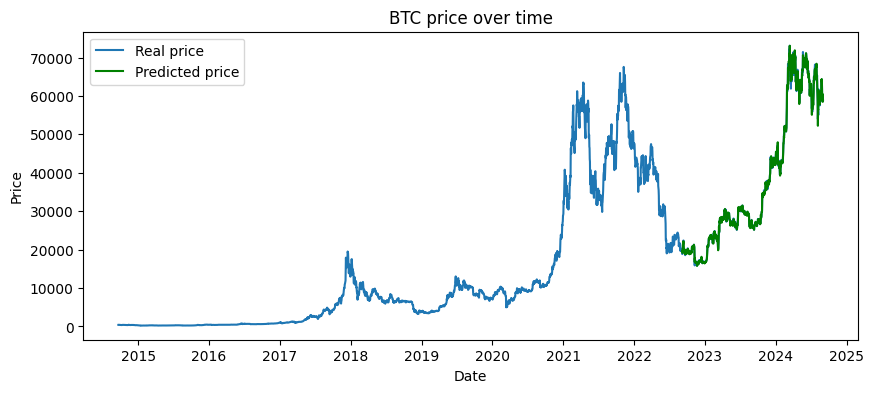

In [14]:
y_pred = pd.Series(y_pred, index=y_test.index)
# y_pred = y_pred.sort_index()
print(y_pred)

plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Line chart
sns.lineplot(data=y_pred, label="Predicted price", color="green")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

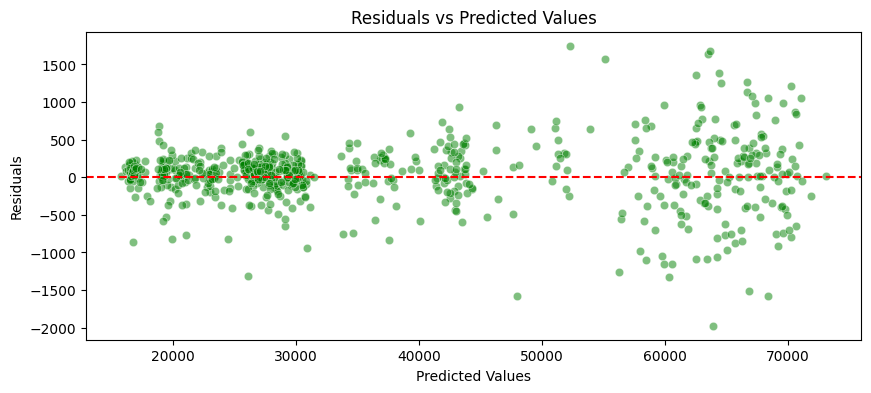

In [15]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals using seaborn
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color="green")
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

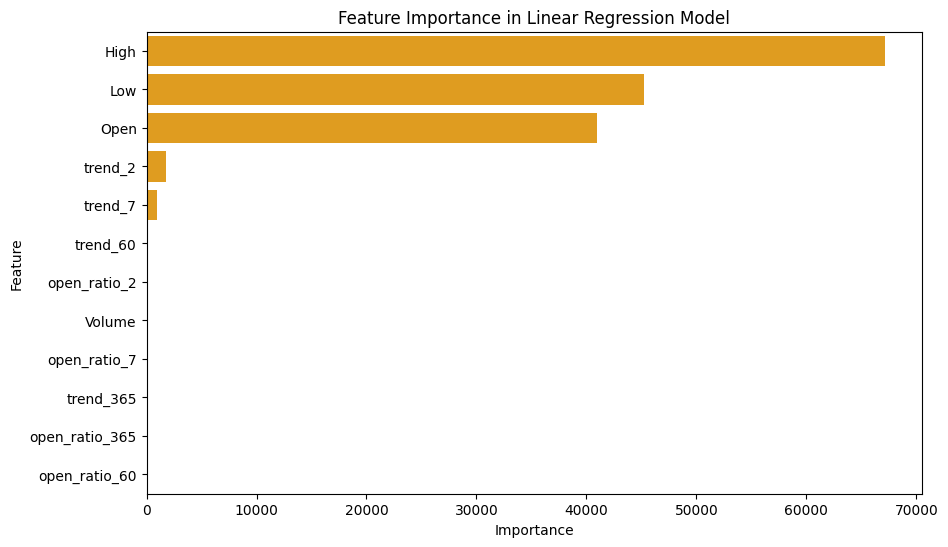

In [16]:
# Get coefficients from the linear regression model
coefficients = best_lr.coef_

# Create a DataFrame for better visualization
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})

# Sort the DataFrame by absolute importance
feature_importance_df['Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="orange")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Linear Regression Model')
plt.show()

/tmp/ipykernel_5405/2821160737.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="coolwarm")


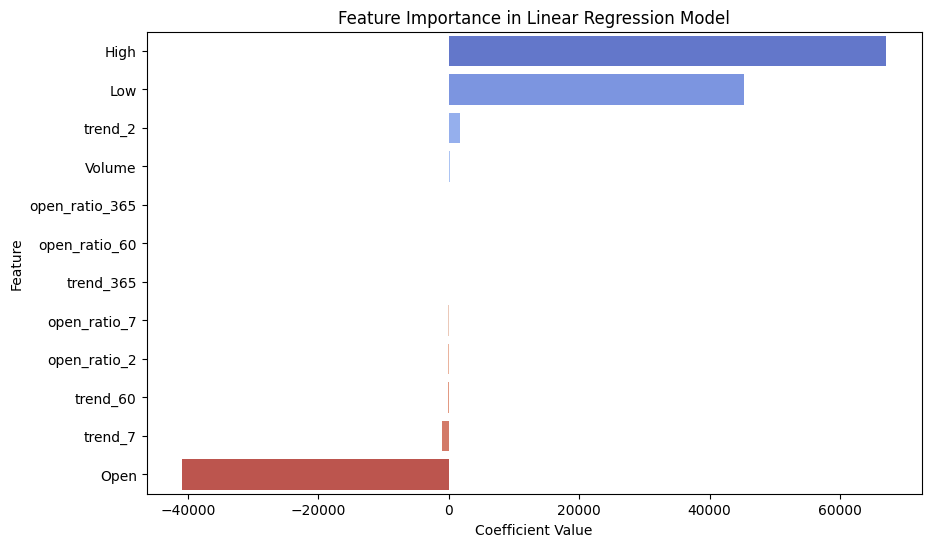

In [17]:
# Get coefficients from the linear regression model
coefficients = best_lr.coef_

# Create a DataFrame for better visualization
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="coolwarm")
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Linear Regression Model')
plt.show()


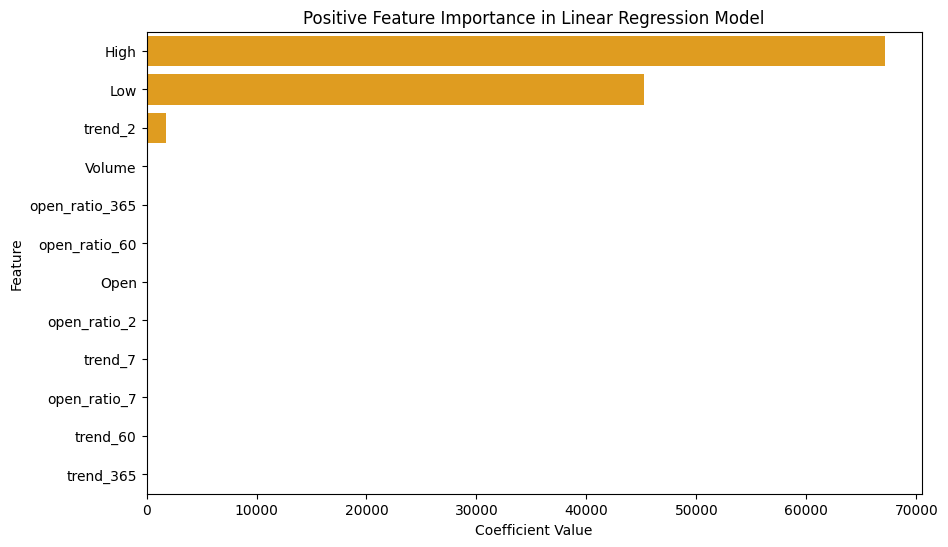

In [18]:
# Get coefficients from the linear regression model
coefficients = best_lr.coef_

# Create a DataFrame for better visualization
feature_names = X.columns
# Set negative coefficients to zero
positive_coefficients = np.where(coefficients > 0, coefficients, 0)

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': positive_coefficients})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="orange")
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Positive Feature Importance in Linear Regression Model')
plt.show()


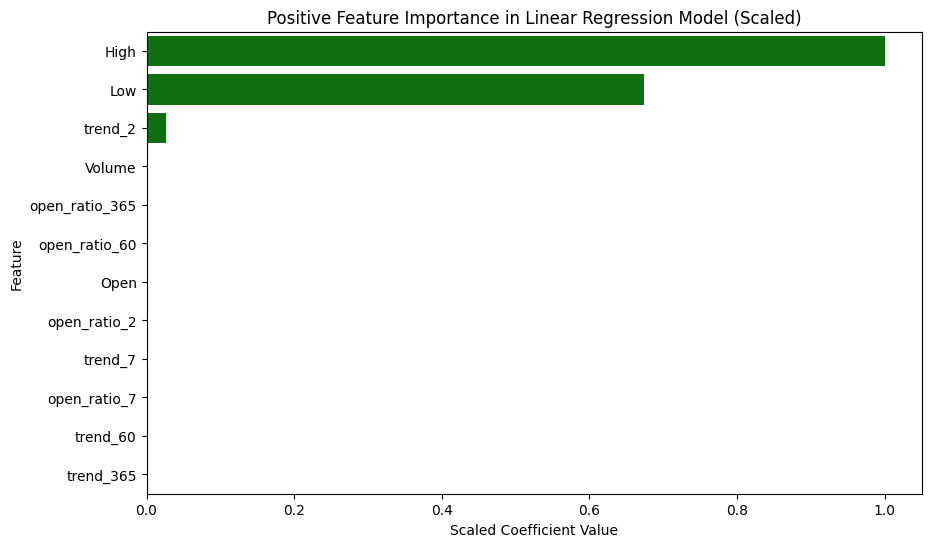

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Get coefficients from the linear regression model
coefficients = best_lr.coef_

# Create a DataFrame for better visualization
feature_names = X.columns

# Set negative coefficients to zero
positive_coefficients = np.where(coefficients > 0, coefficients, 0)

# Scale the positive coefficients to [0, 1]
scaler = MinMaxScaler()
positive_coefficients_scaled = scaler.fit_transform(positive_coefficients.reshape(-1, 1)).flatten()

# Create the DataFrame with scaled coefficients
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': positive_coefficients_scaled})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="green")
plt.xlabel('Scaled Coefficient Value')
plt.ylabel('Feature')
plt.title('Positive Feature Importance in Linear Regression Model (Scaled)')
plt.show()


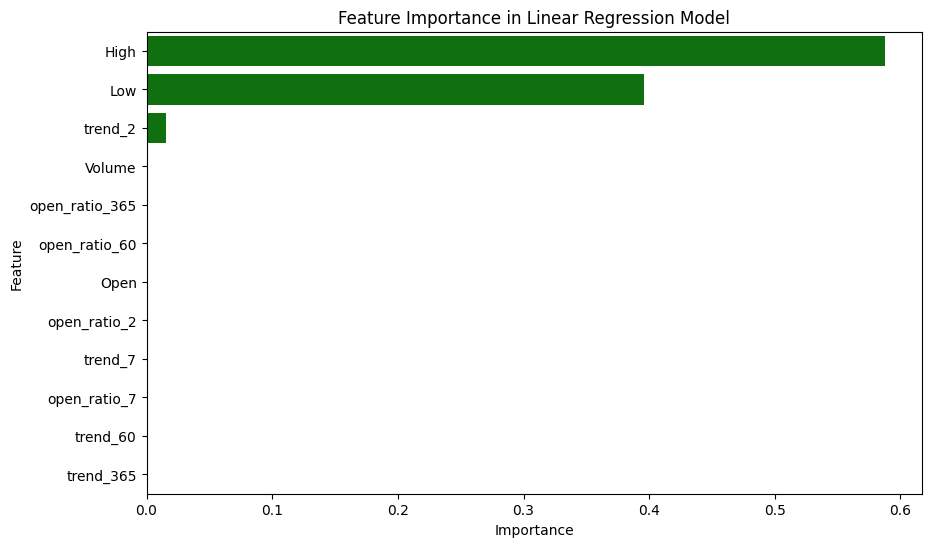

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Get coefficients from the linear regression model
coefficients = best_lr.coef_

# Create a DataFrame for better visualization
feature_names = X.columns

# Set negative coefficients to zero
positive_coefficients = np.where(coefficients > 0, coefficients, 0)

# Normalize the positive coefficients so that their sum equals 1
total_sum = positive_coefficients.sum()
positive_coefficients_normalized = positive_coefficients / total_sum

# Create the DataFrame with normalized coefficients
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': positive_coefficients_normalized})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="green")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Linear Regression Model')
plt.show()

In [21]:
compare = pd.DataFrame({'y_test': y_test, 'y_pred_lr': y_pred}, index=y_test.index)
compare

,y_test,y_pred_lr
Date,,
2022-09-05,19812.371094,19704.599073
2022-09-06,18837.667969,19367.501715
2022-09-07,19290.324219,19165.979661
2022-09-08,19329.833984,19146.527764
2022-09-09,21381.152344,21123.688457
...,...,...
2024-08-27,59504.132812,59876.731734
2024-08-28,59027.625000,58903.257366
2024-08-29,59388.179688,60535.869111


In [22]:
# Save the Series to files

with open('scaled_values_lr.pkl', 'wb') as f:
    pickle.dump(scaled_values, f)
with open('y_pred_lr.pkl', 'wb') as f:
    pickle.dump(y_pred, f)
with open('residuals_lr.pkl', 'wb') as f:
    pickle.dump(residuals, f)